<a href="https://colab.research.google.com/github/Madhura-55/Pridicting-future-sales-using-timeseries-data/blob/main/Time_Series_Analysis_and_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install statsmodels

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [4]:
!git clone https://github.com/Madhura-55/Pridicting-future-sales-using-timeseries-data.git

Cloning into 'Pridicting-future-sales-using-timeseries-data'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.
Resolving deltas: 100% (1/1), done.


In [6]:
df = pd.read_csv('/content/Pridicting-future-sales-using-timeseries-data/airline_passenger_timeseries.csv')
df.head(5)

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


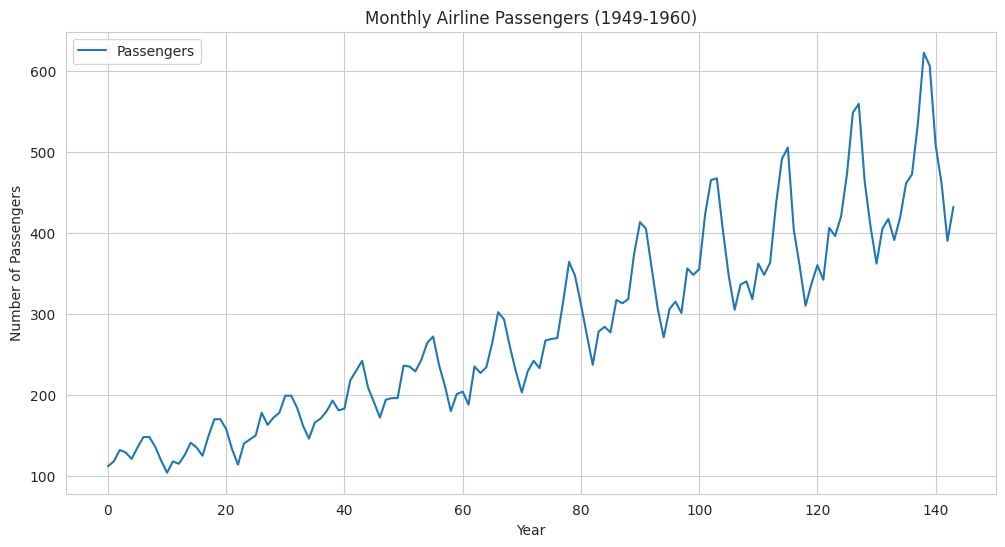

In [7]:
df.plot()
plt.title('Monthly Airline Passengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.show()

**Initial Observation:** The plot clearly shows two strong patterns:
1.  **Upward Trend:** The number of passengers is increasing over time.
2.  **Seasonality:** There is a clear, repeating annual pattern (peaks and troughs within each year).
3.  **Increasing Variance:** The seasonal fluctuations appear to be getting larger over time.

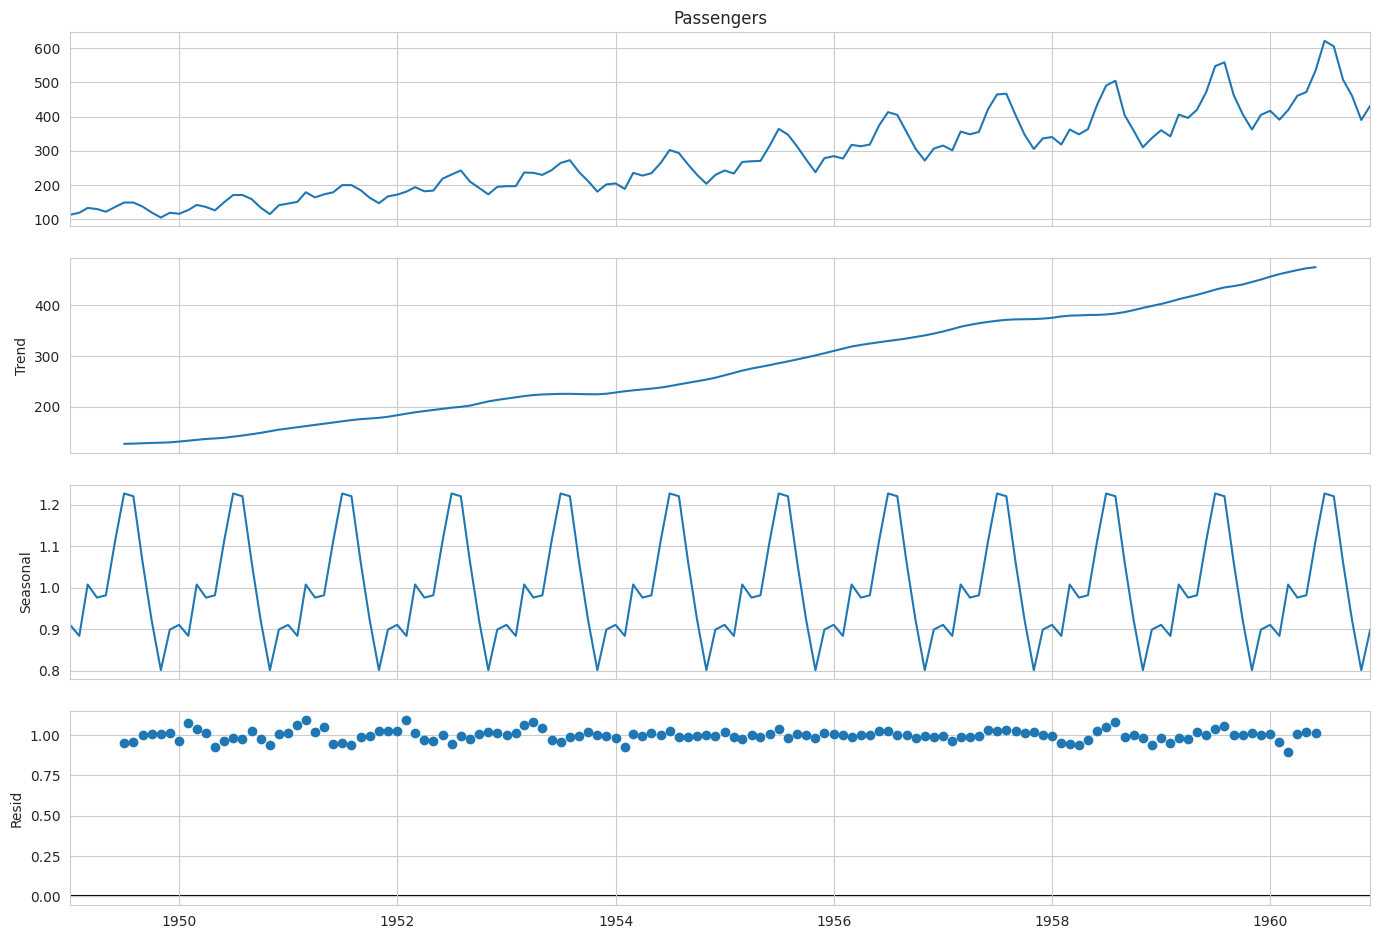

In [8]:
#tsa decompose

df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

decomposition = sm.tsa.seasonal_decompose(df['Passengers'], model='multiplicative')
#multiplicative as variation increasing overtime, if no difference of variation additive would be used

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()